# Formation Graphs

Visualize the canonical node-and-edge topology of each formation in
`graphs.templates.FORMATION_TEMPLATES`. Each panel shows a single
formation as a graph laid out on the pitch: 11 nodes at their template
coordinates (GK at index 0 on the far left), edges built from a fixed
set of **tactical rules** (no distance-based k-NN cut).

Tactical rules encoded in `graphs.templates._build_edges`:
1. GK ↔ every defender.
2. All CBs mutually connected; fullbacks ↔ their outer CB.
3. Every CB ↔ every CDM (3-back fallback: every CB ↔ deepest central mid).
4. CDMs and CAMs ↔ every other midfielder.
5. All central midfielders (CM/CDM/CAM) mutually connected.
6. Wide mids (LM/LAM/RM/RAM) ↔ every central mid.
7. Same-side wide-mid mesh (LM ↔ LAM; RM ↔ RAM).
8. Each fullback ↔ closest same-side wide attacker; falls back to nearest same-side central mid.
9. Wingers ↔ same-side wide mids.
10. Wingers ↔ strikers and CAMs.
11. Strikers mutually connected.
12. Strikers ↔ **CM and CAM only** (CDM is deliberately excluded — the deep pivot reaches the striker through the rest of the midfield, not directly).
13. LAM/RAM ↔ every striker (advanced wide mids feed the front line).
14. **Defensive triangle / double-pivot coverage**: every fullback (LB/RB/LWB/RWB) ↔ every CDM. Closes the FB–outer-CB–CDM triangle and gives the double pivot a direct line to the wing-back.
15. **Wide overload triangle**: LB/LWB ↔ {LM, LAM}; RB/RWB ↔ {RM, RAM}. With rule 7 this closes the FB–LM–LAM triangle on each flank.
16. **True 3-back wide cover**: in formations with three CBs and *no* fullbacks/wing-backs (3-4-3, 3-4-1-2, 3-4-2-1) the outer CBs cover the wide channel themselves, so leftmost CB ↔ LM and rightmost CB ↔ RM. Skipped for 3-5-2 / 5-x-y where wing-backs already bridge that gap.
17. **Lone striker support**: LM ↔ ST and RM ↔ ST when the formation has exactly one striker **and no attacking mids (CAM / LAM / RAM)** — fires for 4-4-1, 4-1-4-1, 5-4-1, 4-5-1, 3-4-3. With two strikers the wide mids already feed the front line through CMs; with attacking mids those nodes already feed the striker (rules 12 / 13), so LM/RM stay one pass away.

Note: front-press connectivity (`ST↔LW/RW`, `LW/RW↔CAM`), mid-block
compactness (`LM/RM↔CM`), `CAM↔LAM/RAM`, and `CDM↔CDM` (double-pivot
mesh) are already covered by rules 4, 6, 10, and 5 respectively.

Sanity checks to look for in each panel:
- Same-side full-backs / wing-backs connect to same-side wingers / wide mids, not to the opposite side.
- GK only connects to the back line; never to a midfielder.
- All CBs in a back-three are mutually connected and each connects to every CDM (or the deepest central mid if no CDM).
- CDM and CAM are hub-like nodes wired to every other midfielder, **but CDM does NOT connect directly to strikers** (rule 12).
- In 3-4-x formations the outer CBs reach out to LM/RM (rule 16); in 4-back / 5-back this doesn't happen.
- LM/RM ↔ ST exists in 4-4-1 / 4-1-4-1 / 5-4-1 / 4-5-1 / 3-4-3 only — not in 3-4-2-1 (LAM/RAM buffer the wide mids from the striker).
- Defensive triangles `LB–LCB–CDM` and `RB–RCB–CDM` are closed (rule 14).
- Wide overload triangles `LB–LM–LAM` / `RB–RM–RAM` are closed (rule 15).
- Front line connects via `LAM/RAM ↔ ST` (rule 13) and `LW/RW ↔ ST/CAM` (rule 10).
- Cross-formation differences are visible (4-4-2 vs 3-5-2 should look noticeably different).

In [11]:
from __future__ import annotations
import sys
from pathlib import Path
import math

HERE = Path.cwd()
ROOT = HERE
while ROOT != ROOT.parent and not (ROOT / 'configs' / 'config.yaml').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from graphs.templates import FORMATION_TEMPLATES, formation_graph

print(f'{len(FORMATION_TEMPLATES)} formation templates registered')

17 formation templates registered


In [12]:
def draw_formation(ax, formation: str) -> None:
    nodes, edges = formation_graph(formation)
    # Pitch background -- x is depth (0=own goal, 100=opponent goal), y is lateral.
    ax.add_patch(mpatches.Rectangle((-5, -5), 115, 90, facecolor='#e6f2e6', edgecolor='gray', lw=0.5))
    # Halfway line
    ax.axvline(50, color='white', lw=1)
    # Edges first so they sit under the nodes.
    for i, j in edges:
        x1, y1 = nodes[i][1], nodes[i][2]
        x2, y2 = nodes[j][1], nodes[j][2]
        ax.plot([x1, x2], [y1, y2], color='gray', lw=1.0, alpha=0.6, zorder=1)
    # Nodes
    for idx, (label, x, y) in enumerate(nodes):
        color = '#ff9933' if label == 'GK' else '#1f78b4'
        ax.scatter(x, y, s=400, color=color, edgecolor='black', linewidth=1.0, zorder=2)
        ax.text(x, y, str(idx), ha='center', va='center', fontsize=8, color='white', zorder=3, fontweight='bold')
        ax.text(x, y - 7, label, ha='center', va='top', fontsize=7, color='black', zorder=3)
    ax.set_xlim(-5, 110); ax.set_ylim(-5, 85)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{formation}  ({len(nodes)} nodes, {len(edges)} edges)', fontsize=10)

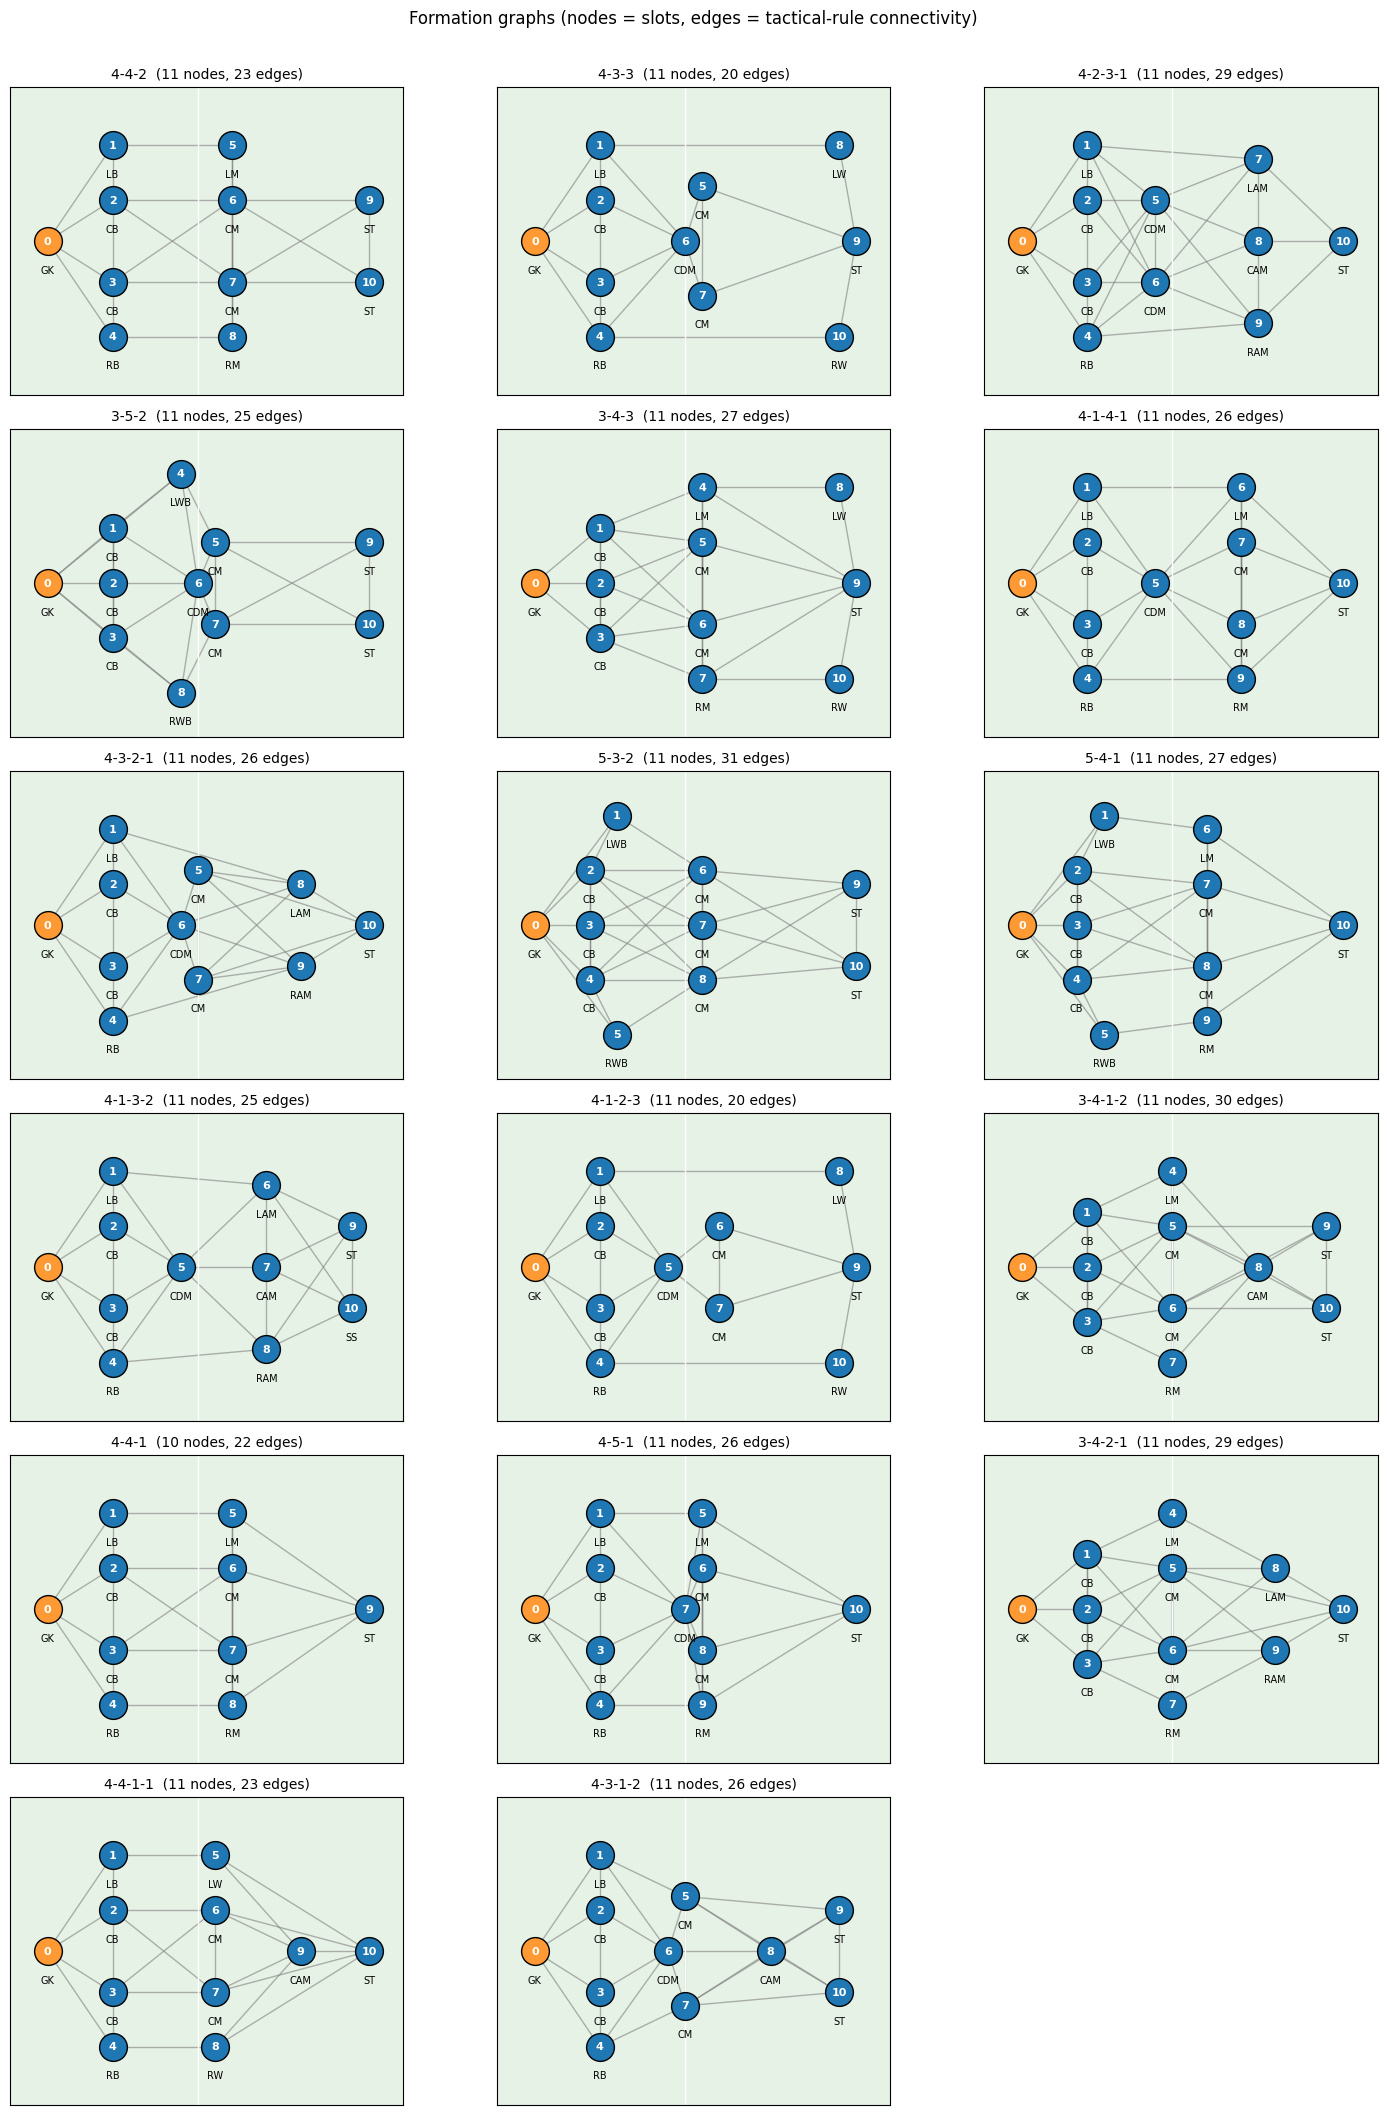

In [13]:
formations = list(FORMATION_TEMPLATES.keys())
ncols = 3
nrows = math.ceil(len(formations) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.0, nrows * 3.5))
axes = axes.flatten()
for ax in axes[len(formations):]:
    ax.set_visible(False)
for ax, f in zip(axes, formations):
    draw_formation(ax, f)
fig.suptitle('Formation graphs (nodes = slots, edges = tactical-rule connectivity)', y=1.005)
fig.tight_layout(); plt.show()

## Per-formation edge listings

For each formation, dump the edges as labeled pairs with their Euclidean
distance on the template pitch. Useful as a quick reference when
implementing the GNN feature builder.

In [14]:
for formation in formations:
    nodes, edges = formation_graph(formation)
    print(f'\n=== {formation} ({len(nodes)} nodes, {len(edges)} edges) ===')
    for i, j in edges:
        li, xi, yi = nodes[i]
        lj, xj, yj = nodes[j]
        d = math.hypot(xi - xj, yi - yj)
        print(f'  {i:>2}.{li:<4} \u2194 {j:>2}.{lj:<4}   dist={d:5.1f}')


=== 4-4-2 (11 nodes, 23 edges) ===
   0.GK   ↔  1.LB     dist= 33.8
   0.GK   ↔  2.CB     dist= 22.5
   0.GK   ↔  3.CB     dist= 22.5
   0.GK   ↔  4.RB     dist= 33.8
   1.LB   ↔  2.CB     dist= 16.0
   1.LB   ↔  5.LM     dist= 35.0
   2.CB   ↔  3.CB     dist= 24.0
   2.CB   ↔  6.CM     dist= 35.0
   2.CB   ↔  7.CM     dist= 42.4
   3.CB   ↔  4.RB     dist= 16.0
   3.CB   ↔  6.CM     dist= 42.4
   3.CB   ↔  7.CM     dist= 35.0
   4.RB   ↔  8.RM     dist= 35.0
   5.LM   ↔  6.CM     dist= 16.0
   5.LM   ↔  7.CM     dist= 40.0
   6.CM   ↔  7.CM     dist= 24.0
   6.CM   ↔  8.RM     dist= 40.0
   6.CM   ↔  9.ST     dist= 40.0
   6.CM   ↔ 10.ST     dist= 46.6
   7.CM   ↔  8.RM     dist= 16.0
   7.CM   ↔  9.ST     dist= 46.6
   7.CM   ↔ 10.ST     dist= 40.0
   9.ST   ↔ 10.ST     dist= 24.0

=== 4-3-3 (11 nodes, 20 edges) ===
   0.GK   ↔  1.LB     dist= 33.8
   0.GK   ↔  2.CB     dist= 22.5
   0.GK   ↔  3.CB     dist= 22.5
   0.GK   ↔  4.RB     dist= 33.8
   1.LB   ↔  2.CB     dist= 16.0
   1

## Degree distribution per formation

Hub-y nodes (CDM, CAM, central CBs in back-three systems) will show
higher degrees by design — they're connected to every midfielder /
defender by construction. Outer wing-backs and wide attackers will have
the lowest degrees.

In [15]:
import pandas as pd
rows = []
for f in formations:
    nodes, edges = formation_graph(f)
    deg = [0] * len(nodes)
    for i, j in edges:
        deg[i] += 1; deg[j] += 1
    rows.append({
        'formation': f, 'n_nodes': len(nodes), 'n_edges': len(edges),
        'mean_deg': sum(deg)/len(deg), 'min_deg': min(deg), 'max_deg': max(deg),
    })
pd.DataFrame(rows).set_index('formation').round(2)

,n_nodes,n_edges,mean_deg,min_deg,max_deg
formation,,,,,
4-4-2,11,23,4.18,3,7
4-3-3,11,20,3.64,2,6
4-2-3-1,11,29,5.27,3,8
3-5-2,11,25,4.55,3,7
3-4-3,11,27,4.91,2,7
4-1-4-1,11,26,4.73,4,8
4-3-2-1,11,26,4.73,4,8
5-3-2,11,31,5.64,3,8
5-4-1,11,27,4.91,3,7
